### PH464/564: Scientific Computing II
***J.S. Hazboun***

___

# Homework 1
### Due: Monday, Oct 6th at 11:59pm Pacific
---

## Handing in Homework

You had the opportunity to practice your git and GitHub skills by submitting HW0 via GitHub. You will need to repeat the process for every homework assigment going forward. Please make sure a copy of the completed assignment is placed in your repos "my_work" directory and pushed to GitHub. Please label files _starting_ with the appropriate hw number. This week's will be `hw1_YOUR_NAME.ipynb`. In addition, I want another document which only has the answers to the questions asked in this HW assignment, along with any figures that you deem appropriate to make yourself understood. Please restate the question where appropriate. Code files will be checked for completeness **only**. I will only consider the answers in the separate `pdf` for grading your understanding of the questions.

**WARNING for devcontainer users:** If you are using the **devcontainer** via `VSCode`, then you will want to make a separate working folder directly in your fork of the class repo and work on your assignment by either _copying_ a notebook in there or opening a new one in that folder. The reason is that the _repo_ has the devcontainer instructions and when you open `VSCode` it recognizes this and starts up the devcontainer.  

## Problem 1



Consider a family with two children. Assume that the probability of females and males being born is equal, i.e. $p(F)=0.5$ and $p(M)=0.5$. Remember that "given" means your calculation is conditioned on some already fixed data or outcome. 

1) What is the probability of one male and one female **GIVEN** that the first child is male. 

2) What is the probability of two females **GIVEN** that at least one child is female.

3) What is the probability of two females **GIVEN** that the older child is female.

You will find it easiest to answer these questions by sketching a "tree diagram" to visualize the options for the oldest child, and the branching options for the youngest child. 

Either write your solution as Markdown/Latex below, or paste in a scanned image of your handwritten solution.

### Solution

1) *(To get you started)* If the first child is male, then the only unknown is the sex of the second child. We want the second child to be female, which has a probability of 0.5. Thus, $p(F,M |C_1=M) = 0.5$. 

2) There are four combinations of the two children: FF, FM, MF, MM. 3 of these have one female. Given that we know at least one child is female, this gives combinations FF, FM, and MF a probability of 1/3 each. Thus the probability of getting FF is 1/3.

3) If the first child is female, then the possible combinations are FF and FM each with a probability of 1/2. Thus, the probability of FF here is 1/2.

## Problem 2

1) Use `numpy` to draw $1000$ random samples from a uniform distribution between $0.1$ and $10$, and store these samples as $x$.

2) Use matplotlib to make a histogram of these samples. Try to make this as aesthetically pleasing as possible (within reason).

3) Compute the base-10 log of your array $x$, and store this as $y$.

4) Make another histogram for $y$. Using the equation to transform probability distributions in `Lecture_2`, write here what the theoretical pdf of $y$ is, and overplot it onto your histogram.

5) Compute the mean of $x$ and the mean of $y$. Now compute the median of $x$ and the median of $y$. You should note that the means are different, but the medians (as it is a cumulative statistic) are the same. The mean is affected by the scale of the sample values, but the median only depends on the ordering of the samples. Monotonic transformations (like taking the log) do not change the ordering of samples.

### Solution

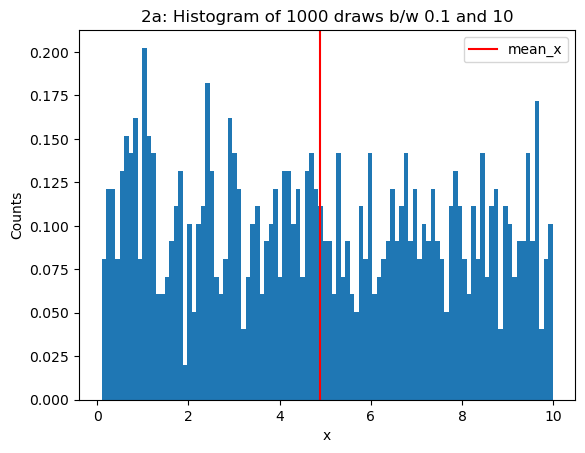

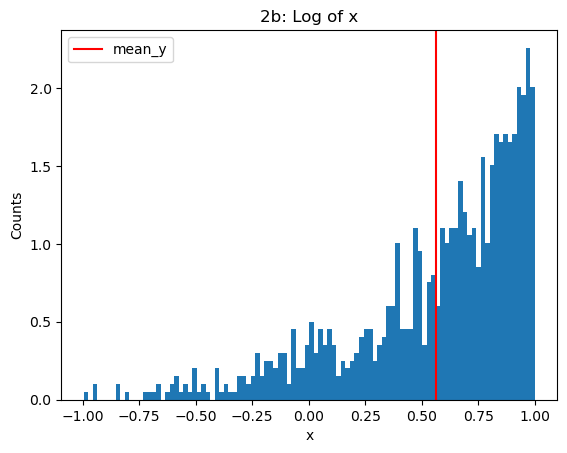

In [27]:
import numpy as np
from matplotlib import pyplot as plt
x = np.random.uniform(0.1,10,1000)
mean_x = np.mean(x)
y = np.log10(x)
mean_y = np.mean(y)
plt.hist(x, bins=100, density=True)
plt.axvline(x = mean_x, color='r', label = 'mean_x')
plt.ylabel('Counts')
plt.xlabel('x')
plt.legend()
plt.title('2a: Histogram of 1000 draws b/w 0.1 and 10')
plt.show()

plt.hist(y,bins=100, density=True)
plt.title('2b: Log of x')
plt.axvline(x = mean_y, color='r', label = 'mean_y')
plt.ylabel('Counts')
plt.xlabel('x')
plt.legend()
plt.show()

$$p(y) = \left|\frac{dx}{dy}\right| p(x)$$

$p(x)$ is uniform random between 0.1 and 10 and $p(y) = \log_{10}(x)$. Following the example from Lecture 2, 

$$y = \log_{10}(x) \Rightarrow 10^y = x$$

$$p(y) = \left|\frac{dx}{dy}\right| p(x) = \left| 10^y \ln(10) \right| p(x)$$

$$p(x) = \frac{1}{10-0.1} = \frac{1}{9.9}$$

$$p(y) = \frac{10^y \ln(10)}{9.9}$$

That is, between

$$ \log_{10}(0.1) < y < \log_10{10} $$

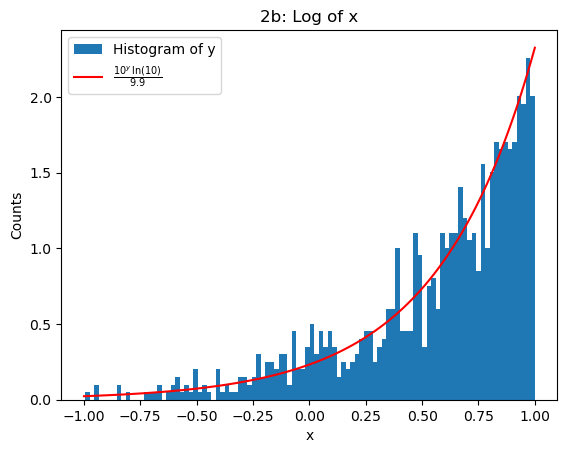

In [64]:
y_theory = np.linspace(np.log10(0.1), np.log10(10), 100)
f_y = (10**y_theory * np.log(10)) / 9.9

plt.hist(y, bins=100, density=True, label='Histogram of y')
plt.title('2b: Log of x')
plt.plot(y_theory, f_y, color='r', label=r'$\frac{10^{y}\,\ln(10)}{9.9}$')
plt.ylabel('Counts')
plt.xlabel('x')
plt.legend()
plt.show()

In [29]:
print(f'Mean of x: {mean_x} \nMean of y: {mean_y}')
med_x = np.median(x)
med_y = np.median(y)
print(f'Median of x: {med_x} \nMedian of y: {med_y}')

Mean of x: 4.894752952666564 
Mean of y: 0.5631812574017702
Median of x: 4.772374493187636 
Median of y: 0.678734490619884


## Problem 3

This question is about IQ. It's a flawed and questionable metric, but useful for this problem. By definition, IQ is calibrated as a Gaussian distribution with $\mu=100$ and $\sigma=15$. 

1) Create a `scipy.stats` Gaussian object with these properties. Plot the distribution, and print out 10 random draws, along with the pdf at $x=145$. 

2) Access the `cdf` property of the Gaussian object and plot it over the same $x$-range as in (1) but in a different figure. 

3) What fraction of people have IQ > 145? *Hint: investigate all the properties of the Gaussian Python object from part (1) to find the relevant property that gives you this, or perform a calculation involving the cdf.*

4) What IQ corresponds to "one in a million"?

### Solution

The 10 random draws are... 

[114.43720313 121.99067971 108.09146225  91.80809028  98.21543937
  97.08114175  82.17979598  94.55587221  96.22832356  83.03193138]

The pdf at IQ=145 is 0.0002954565607958672


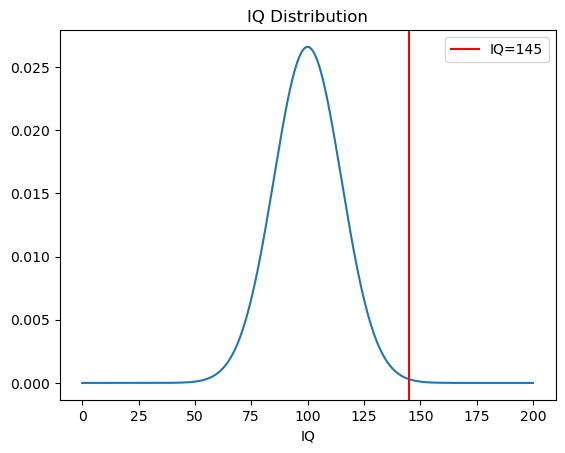

In [47]:
import scipy.stats
from scipy.stats import norm

distIQ = scipy.stats.norm(loc=100, scale=15)
x = np.linspace(0, 200, 500)

#Crucnhing

draws = distIQ.rvs(10)
print(f'The 10 random draws are... \n\n{draws}\n\nThe pdf at IQ=145 is {distIQ.pdf(145)}')


#Plotting
plt.plot(x, distIQ.pdf(x))
plt.axvline(x=145, color='red', label='IQ=145')
plt.title('IQ Distribution')
plt.xlabel('IQ')
plt.legend()
plt.show()

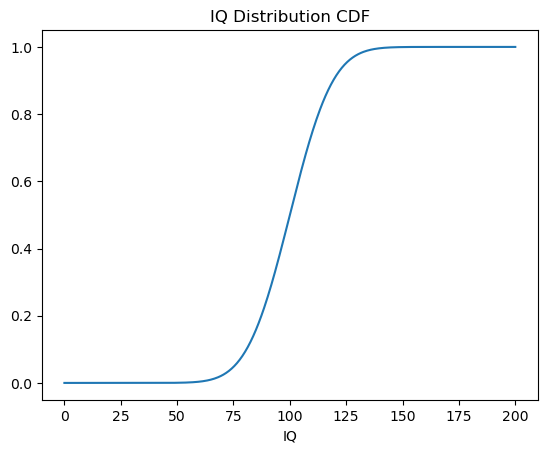

In [50]:
plt.plot(x, distIQ.cdf(x))
plt.title('IQ Distribution CDF')
plt.xlabel('IQ')
plt.show()

$$\mathrm{cdf}(x|\mu,\sigma) = \int_{-\infty}^{x'} p(x'|\mu,\sigma) dx',$$

for this problem, we want to know what fraction have an IQ above 145 so we will flip the bounds to look the other way.

$$\mathrm{cdf}(x|\mu,\sigma) = \int_{145}^{\infty} p(x'|\mu,\sigma) dx' = \mathrm{cdf}(\infty) - \mathrm{cdf}(145) = 1 - \mathrm{cdf}(145)$$

$$ \mathrm{cdf} = \int p(x' | \mu=100, \sigma=15)dx'$$

$$= \int_{145}^{\infty} \frac{1}{15\sqrt{2\pi}} \exp\left(\frac{-(x-100)^2}{2*15^2}\right) dx'$$

$$=0.001349898031630095$$

$=0.1349%$ of people have an IQ > 145.

(by integral calculator)

In [54]:
one_in_million = 1/10**6
print(f'One in a Million = {one_in_million}')

One in a Million = 1e-06


$1 \times 10^{-6} = 1 - \mathrm{cdf}(?)$ is the IQ that is one in a million

In [61]:
qmillion = distIQ.ppf(1 - 1/1e6)
lowmillion = distIQ.ppf(1/1e6)
print(f'The Magical IQ is {round(qmillion)} or {round(lowmillion)}')

The Magical IQ is 171 or 29
